In [ ]:
'''Norbert Rama Hadiprodjo, 1010607666'''

'Norbert Rama Hadiprodjo, 1010607666'

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
#Unzipping Data from Drive

path = "/content/drive/MyDrive/UofT/APS360/Project"

print(os.listdir(path))

['real.zip', 'fakeV2.zip']


In [ ]:
import zipfile

zip_fake = "/content/drive/MyDrive/UofT/APS360/Project/fakeV2.zip"
zip_real = "/content/drive/MyDrive/UofT/APS360/Project/real.zip"

extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_fake, 'r') as zip_ref:
    zip_ref.extractall(extract_path + "/fake")

with zipfile.ZipFile(zip_real, 'r') as zip_ref:
    zip_ref.extractall(extract_path + "/real")

print("Extraction complete")

Extraction complete


In [ ]:
fake_path = "/content/dataset/fake/fake-v2"
real_path = "/content/dataset/real"

print("Fake images:", len(os.listdir(fake_path)))
print("Real images:", len(os.listdir(real_path)))

Fake images: 17857
Real images: 3781


Fake images: 17857
Real images: 3781


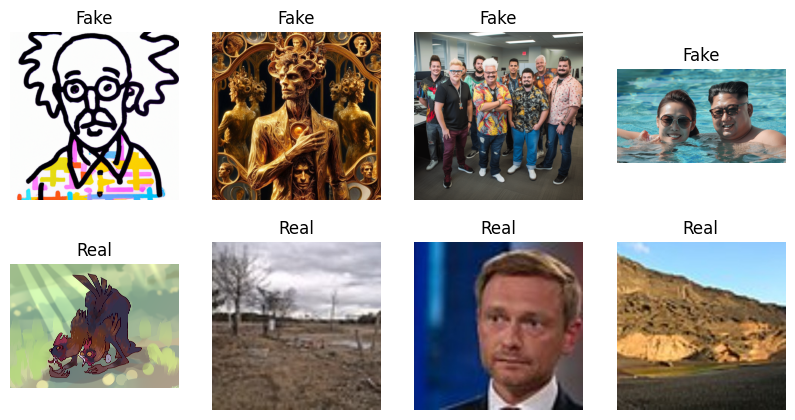

In [ ]:
fake_path = "/content/dataset/fake/fake-v2"
real_path = "/content/dataset/real"

print("Fake images:", len(os.listdir(fake_path)))
print("Real images:", len(os.listdir(real_path)))


#Visualizing Data to Images
import matplotlib.pyplot as plt
from PIL import Image
import random

Image.MAX_IMAGE_PIXELS = None

fake_images = os.listdir(fake_path)
real_images = os.listdir(real_path)

plt.figure(figsize=(10,5))

for i in range(4):
    img = Image.open(fake_path + "/" + random.choice(fake_images))
    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title("Fake")
    plt.axis("off")

for i in range(4):
    img = Image.open(real_path + "/" + random.choice(real_images))
    plt.subplot(2,4,i+5)
    plt.imshow(img)
    plt.title("Real")
    plt.axis("off")

plt.show()

In [ ]:
#Labelling the Data
data = []

for img in os.listdir(fake_path):
    if img.endswith((".png", ".jpg", ".jpeg")):
        data.append([fake_path + "/" + img, 1])   # 1 = fake

for img in os.listdir(real_path):
    if img.endswith((".png", ".jpg", ".jpeg")):
        data.append([real_path + "/" + img, 0])   # 0 = real

df = pd.DataFrame(data, columns=["image_path", "label"])

df.head()

,image_path,label
0,/content/dataset/fake/fake-v2/23999.png,1
1,/content/dataset/fake/fake-v2/13379.png,1
2,/content/dataset/fake/fake-v2/13294.png,1
3,/content/dataset/fake/fake-v2/12934.jpg,1
4,/content/dataset/fake/fake-v2/19797.png,1


In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df.label)

val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df.label)

print(len(train_df), len(val_df), len(test_df))

15144 3245 3246


In [ ]:
#BUILDING BASELINE
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import cv2

In [ ]:
def extract_features(image_path):

    img = cv2.imread(image_path)

    img = cv2.resize(img, (128,128))     # smaller for baseline
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    feature = img.flatten()              # convert to vector

    return feature

In [ ]:
train_df_small = train_df.sample(n=4000, random_state=42)
test_df_small = test_df.sample(n=1000, random_state=42)

print("Baseline train size:", len(train_df_small))
print("Baseline test size:", len(test_df_small))

Baseline train size: 4000
Baseline test size: 1000


In [ ]:
X_train = []
y_train = []

for idx, row in train_df_small.iterrows():   # changed from train_df

    feat = extract_features(row["image_path"])

    X_train.append(feat)
    y_train.append(row["label"])

X_train = np.array(X_train)
y_train = np.array(y_train)

print("Training data shape:", X_train.shape)

Training data shape: (4000, 16384)


In [ ]:
X_test = []
y_test = []

for idx, row in test_df_small.iterrows():   # changed from test_df

    feat = extract_features(row["image_path"])

    X_test.append(feat)
    y_test.append(row["label"])

X_test = np.array(X_test)
y_test = np.array(y_test)

print("Test data shape:", X_test.shape)

Test data shape: (1000, 16384)


In [ ]:
svm = SVC(kernel='rbf', probability=True)

print("Training baseline SVM...")

svm.fit(X_train, y_train)

Training baseline SVM...


SVC(probability=True)

In [ ]:
pred = svm.predict(X_test)

baseline_accuracy = accuracy_score(y_test, pred)

print("Baseline Model Accuracy:", baseline_accuracy)

Baseline Model Accuracy: 0.834


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

def predict_baseline(image_path):

    # Load image
    img = Image.open(image_path).convert("L")   # grayscale
    img = img.resize((128,128))

    # Convert to numpy and flatten
    img_array = np.array(img).flatten().reshape(1, -1)

    # Predict
    pred = svm.predict(img_array)[0]
    prob = svm.predict_proba(img_array)[0][1]

    # Display image
    plt.imshow(img, cmap="gray")
    plt.title(f"Prediction: {'AI Generated' if pred==1 else 'Real'}\nProbability: {prob:.2f}")
    plt.axis("off")
    plt.show()

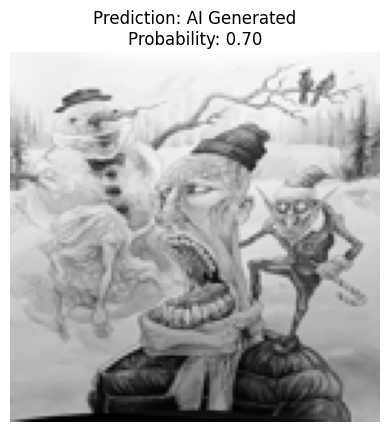

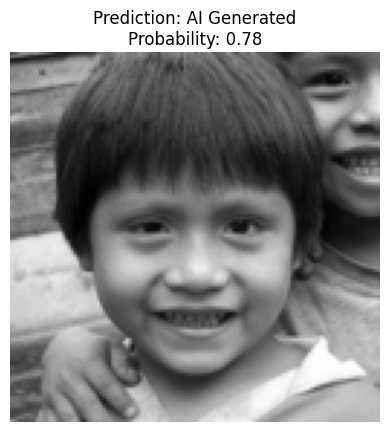

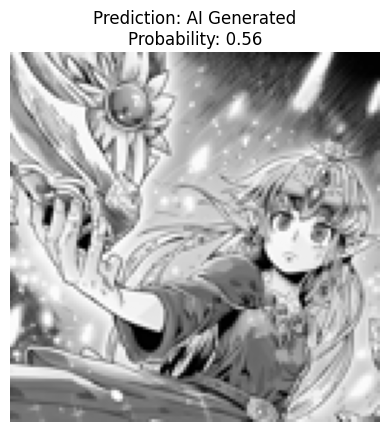

In [ ]:
import random

for i in range(3):

    idx = random.randint(0, len(test_df)-1)
    img_path = test_df.iloc[idx]["image_path"]

    predict_baseline(img_path)

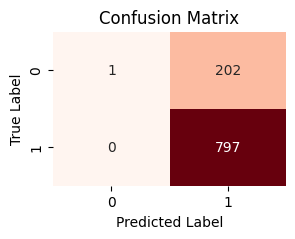

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, pred)

# Plot
plt.figure(figsize=(3,2))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", cbar=False)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
#BUILDING MODEL

#1 - Define Image Transformations
IMG_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1),
    transforms.ToTensor(),
])

In [ ]:
#2 - Create a custom dataset loader

class ImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["image_path"]
        label = self.df.iloc[idx]["label"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
#3-Create DataLoaders
train_dataset = ImageDataset(train_df, transform=train_transform)
val_dataset = ImageDataset(val_df, transform=transform)
test_dataset = ImageDataset(test_df, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [ ]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(pretrained=True)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1)

model = model.to(DEVICE)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 134MB/s]


In [ ]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
def train_epoch(loader, model, optimizer):

    model.train()
    total_loss = 0

    for images, labels in loader:

        images = images.to(DEVICE)
        labels = labels.float().to(DEVICE)

        outputs = model(images).squeeze()

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def evaluate(loader, model):

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images).squeeze()
            preds = torch.sigmoid(outputs) > 0.5

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [ ]:
train_losses = []
val_accuracies = []

for epoch in range(5):

    train_loss = train_epoch(train_loader, model, optimizer)
    val_acc = evaluate(val_loader, model)

    train_losses.append(train_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}")
    print("Train loss:", train_loss)
    print("Val accuracy:", val_acc)

Epoch 1
Train loss: 0.17672355040389148
Val accuracy: 0.9540832049306626
Epoch 2
Train loss: 0.092534872018516
Val accuracy: 0.9617873651771957
Epoch 3
Train loss: 0.057885143291873206
Val accuracy: 0.9476117103235747
Epoch 4
Train loss: 0.043707134657714294
Val accuracy: 0.9605546995377504
Epoch 5
Train loss: 0.03783450636448818
Val accuracy: 0.9645608628659477


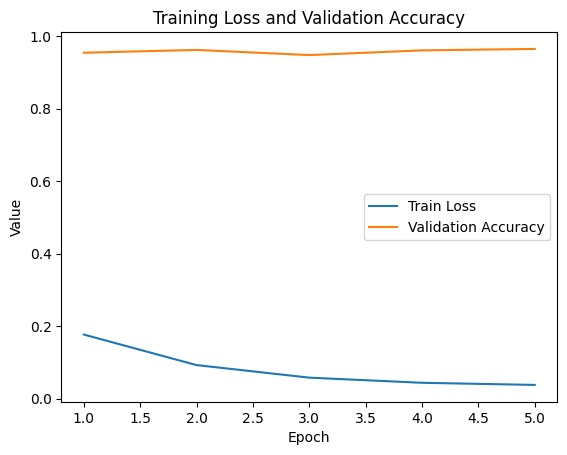

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()

plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Loss and Validation Accuracy")
plt.legend()


plt.show()

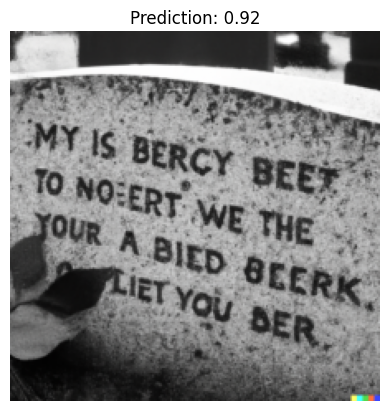

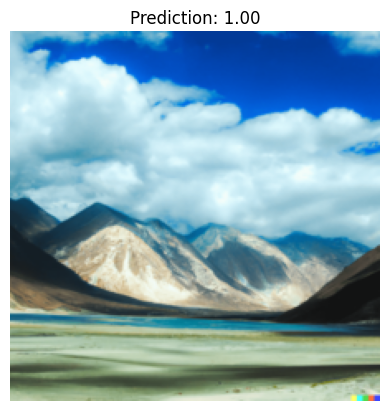

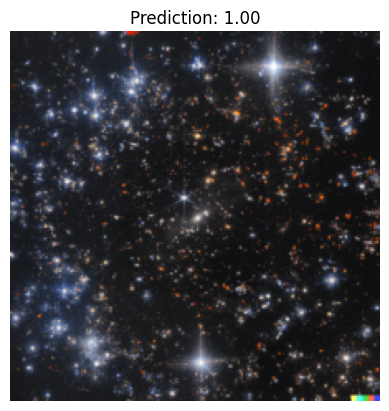

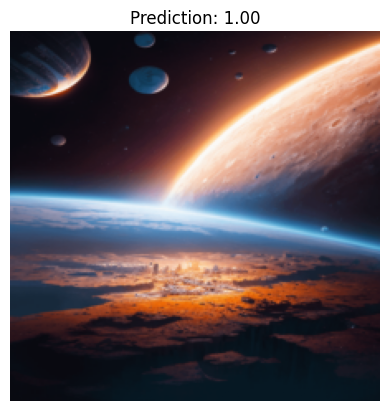

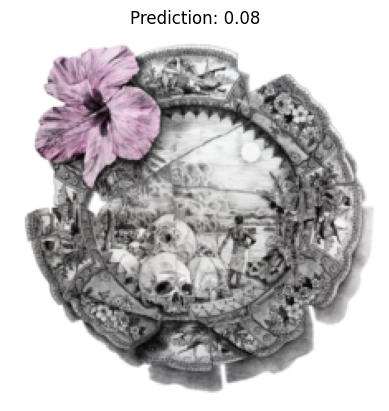

In [ ]:
import random

model.eval()

images, labels = next(iter(test_loader))
images = images.to(DEVICE)

outputs = model(images).squeeze()
probs = torch.sigmoid(outputs)

indices = random.sample(range(len(images)), 5)

for i in indices:
    plt.imshow(images[i].cpu().permute(1,2,0))
    plt.title(f"Prediction: {probs[i]:.2f}")
    plt.axis("off")
    plt.show()

In [ ]:
train_acc = evaluate(train_loader, model)
print("Train Accuracy:", train_acc)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Accuracy: 0.9945192815636555


In [ ]:
val_acc = evaluate(val_loader, model)
print("Validation Accuracy:", val_acc)

Validation Accuracy: 0.9645608628659477


In [ ]:
#TESTING FROM UNSEEN BUT SAME DATASET
test_acc = evaluate(test_loader, model)
print("Test accuracy:", test_acc)

Test accuracy: 0.9602587800369686


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


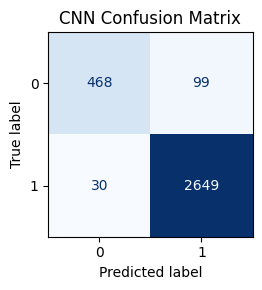

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images).squeeze()
        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(3,3))

disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues", ax=ax, colorbar=False)

ax.set_title("CNN Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
#TESTING FROM NEW DATASET
real_test_path = "/content/drive/MyDrive/UofT/APS360/Project/APS360_Real"
fake_test_path = "/content/drive/MyDrive/UofT/APS360/Project/APS360_Fake"

In [ ]:
test_images = []
test_labels = []

valid_ext = (".png", ".jpg", ".jpeg")

# Fake = 1
for img in os.listdir(fake_test_path):
    if img.lower().endswith(valid_ext):
        test_images.append(os.path.join(fake_test_path, img))
        test_labels.append(1)

# Real = 0
for img in os.listdir(real_test_path):
    if img.lower().endswith(valid_ext):
        test_images.append(os.path.join(real_test_path, img))
        test_labels.append(0)

In [ ]:
def count_images(path):
    return len([
        f for f in os.listdir(path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

print("Real unseen images:", count_images(real_test_path))
print("Fake unseen images:", count_images(fake_test_path))

Real unseen images: 43
Fake unseen images: 26


In [ ]:
unseen_df = pd.DataFrame({
    "image_path": test_images,
    "label": test_labels
})

In [ ]:
#BASELINE UNSEEN
# reuse your extract_features function
X_unseen = []
y_unseen = []

for idx, row in unseen_df.iterrows():
    feat = extract_features(row["image_path"])
    X_unseen.append(feat)
    y_unseen.append(row["label"])

X_unseen = np.array(X_unseen)
y_unseen = np.array(y_unseen)

baseline_unseen_acc = svm.score(X_unseen, y_unseen)

print("Baseline Unseen Accuracy:", baseline_unseen_acc)

Baseline Unseen Accuracy: 0.37681159420289856


In [ ]:
#MODEL UNSEEN
unseen_dataset = ImageDataset(unseen_df, transform=transform)
unseen_loader = DataLoader(unseen_dataset, batch_size=32)

In [ ]:
unseen_acc = evaluate(unseen_loader, model)
print("Unseen Test Accuracy:", unseen_acc)

Unseen Test Accuracy: 0.4057971014492754


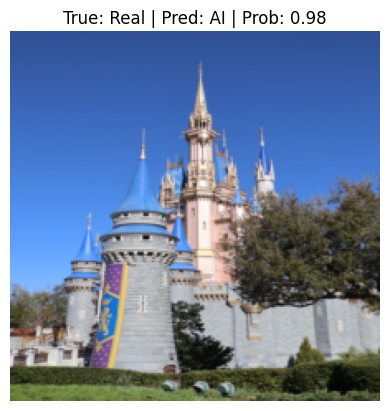

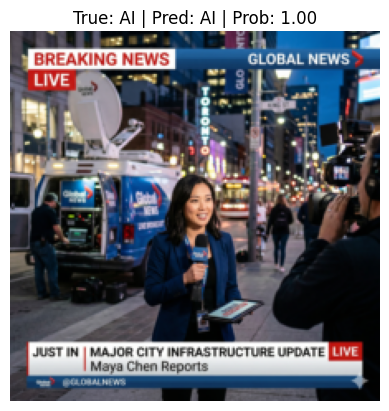

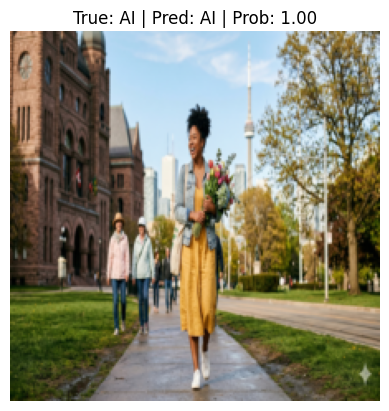

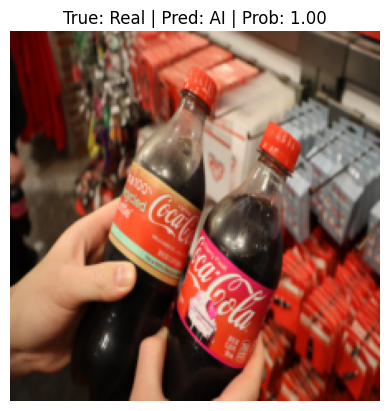

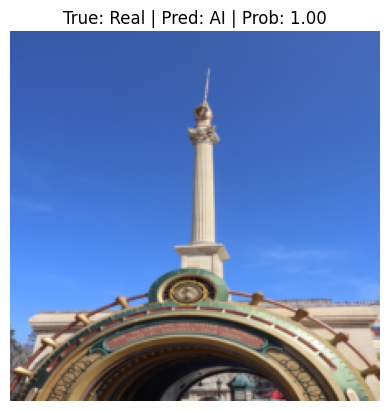

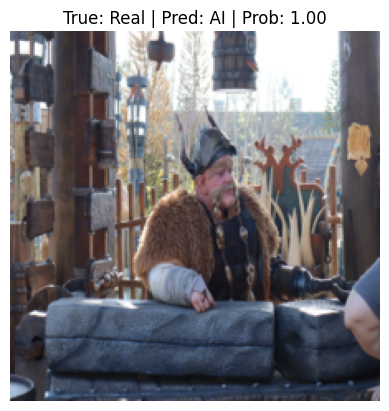

In [ ]:
import random
from PIL import ImageOps

model.eval()

for i in range(6):

    idx = random.randint(0, len(unseen_df)-1)
    img_path = unseen_df.iloc[idx]["image_path"]
    true_label = unseen_df.iloc[idx]["label"]

    img = Image.open(img_path)
    img = ImageOps.exif_transpose(img)
    img = img.convert("RGB")
    input_img = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(input_img).squeeze()
        prob = torch.sigmoid(output).item()
        pred = 1 if prob > 0.5 else 0

    plt.imshow(input_img.squeeze().permute(1,2,0).cpu())
    plt.title(f"True: {'AI' if true_label==1 else 'Real'} | Pred: {'AI' if pred==1 else 'Real'} | Prob: {prob:.2f}")
    plt.axis("off")
    plt.show()